# Разработка A/B-тестирования и анализ результатов

- Автор: Новикова Мария Федоровна
- Дата: 02.07.2025
\

### Цели и задачи проекта

<font color='#777778'> Цель проекта: 
- разработка А/В тестирования и анализ результатов.</font>

<font color='#777778'> Задачи проекта:
- ознакомление с данными;
- проверка корректности данных, в том числе приведение предобработки;
- проведение статистических тестов;
- составление итоговых выводов и результатов по итогам проведенного анализа. </font>

### Содержимое проекта


<font color='#777778'>Оглавление:
* [1. 1  Описание данных](#1)
    * [1.1 Промежуточный вывод](#1.1)
    * [1.2 Подготовка единого датафрейма](#1.2)
* [2.1  1. Работа с историческими данными (EDA)](#2.1)
    * [2.1.1  1.1. Загрузка исторических данных](#2.1.1)    
    * [2.1.2  1.2. Знакомство с данными](#2.1.2)
    * [2.1.3  1.3. Анализ числа регистраций](#2.1.3)
    * [2.1.4  1.4. Анализ числа просмотренных страниц](#2.1.4)
    * [2.1.5  1.5. Доля пользователей, просмотревших более четырёх страниц](#2.1.5)
* [2.2  2. Подготовка к тесту](#2.2)
    * [2.2.1  2.1 Формулировка нулевой и альтернативной гипотез](#2.2.1)
    * [2.2.2  2.2. Расчёт размера выборки](#2.2.2)
    * [2.2.3  2.3. Расчёт длительности A/B-теста](#2.2.3)
* [2.3  3. Мониторинг А/В-теста](#2.3)
    * [2.3.1  3.1. Проверка распределения пользователей](#2.3.1)
    * [2.3.2  3.2. Проверка пересечений пользователей](#2.3.2)
    * [2.3.3  3.3. Равномерность разделения пользователей по устройствам](#2.3.3)
    * [2.3.4  3.4. Равномерность распределения пользователей по регионам](#2.3.4)
    * [2.3.5  3.5. Вывод после проверки A/B-теста](#2.3.5)
* [2.4  4. Проверка результатов A/B-теста](#conclusions)(#2.4)
    * [2.4.1  4.1. Получение результатов теста и подсчёт основной метрики](#2.4.1)
    * [2.4.2  4.2. Проверка корректности результатов теста](#2.4.2)
    * [2.4.3  4.3. Сравнение доли успешных сессий](#2.4.3)
    * [2.4.4  4.4. Насколько статистически значимо изменение ключевой метрики](#2.4.4)
    * [2.4.5  4.5. Вывод по результатам A/B-эксперимента](#2.4.5)</font>
    
---

## Описание данных<a id='1'></a>

Таблицы:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. 

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. 

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.



### 1. Работа с историческими данными (EDA) <a id='2.1'></a>

#### 1.1. Загрузка исторических данных<a id='2.1.1'></a>

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns 

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy.stats import ttest_ind
from math import floor
from statsmodels.stats.proportion import proportions_ztest

# Загрузим библиотеку для построения диаграммы Венна
try:
    from matplotlib_venn import venn2
except ImportError:
    !pip install matplotlib-venn -q
    from matplotlib_venn import venn2
    
    

In [2]:
# добавим фукнцию для подписи значений на график
def autolabel(rects, labels=None, height_factor=1.01):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        if labels is not None:
            try:
                label = labels[i]
            except (TypeError, KeyError):
                label = ' '
        else:
            label = '%.2f' % height
        ax.text(rect.get_x() + rect.get_width()/2., height_factor*height,
                '{}'.format(label),
                ha='center', va='bottom')

In [3]:
# Установим опцию, чтобы выводить на экран все столбцы датафрейм для упрощения анализа.
pd.set_option('display.max_columns', None)

In [4]:
# Выгружаем данные в переменные 
sessions_history_df = pd.read_csv('___/sessions_project_history.csv')

In [5]:
# Выводим 5 первых строк
sessions_history_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [6]:
# Выводим информацию о датафрейме
sessions_history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


In [7]:
# Меняем тип данных на datetime64 в датафрейме
for column in ['session_date', 'session_start_ts', 'install_date']:
    sessions_history_df[column] = pd.to_datetime(sessions_history_df[column])

In [8]:
# Проверим данные в столбцах, какие уникальные значения имеются в столбце
nuniq_sessions_history_df = pd.DataFrame({'Кол-во уникальных значений': sessions_history_df.nunique()})
nuniq_sessions_history_df

,Кол-во уникальных значений
user_id,134039
session_id,435924
session_date,44
session_start_ts,373059
install_date,31
session_number,10
registration_flag,2
page_counter,7
region,3
device,4


In [9]:
# Проверим данные в столбцах, какие уникальные значения имеются в столбце
columns = ['session_number', 'registration_flag', 'page_counter', 'region', 'device']
for column in columns:
    uniq = sessions_history_df[column].unique()
    print(f'В столбце {column} имеются уникальные значения {uniq}')

В столбце session_number имеются уникальные значения [ 1  2  3  4  5  6  7  8  9 10]
В столбце registration_flag имеются уникальные значения [0 1]
В столбце page_counter имеются уникальные значения [3 4 5 1 2 6 7]
В столбце region имеются уникальные значения ['CIS' 'MENA' 'EU']
В столбце device имеются уникальные значения ['iPhone' 'Android' 'PC' 'Mac']


In [10]:
# Проверим данные в столбцах, какие временные интервалы указаны в столбцах
columns = ['session_date', 'session_start_ts', 'install_date']
for column in columns:
    min_column = sessions_history_df[column].min()
    max_column = sessions_history_df[column].max()
    print(f'В столбце {column} рассматривается период от {min_column} до {max_column}')

В столбце session_date рассматривается период от 2025-08-11 00:00:00 до 2025-09-23 00:00:00
В столбце session_start_ts рассматривается период от 2025-08-11 00:00:25 до 2025-09-23 23:51:46
В столбце install_date рассматривается период от 2025-08-11 00:00:00 до 2025-09-10 00:00:00


**Итог по разделу:**
- Были загружены минимально необходимые библиотеки для работы 
- Загружены исторические данные по сессиям пользователей
- Изменены типы данных на тип datetime в столбцах 'session_date', 'session_start_ts', 'install_date'. В прочих столбцах данные соответствуют верному типу данных.
- Проведена проверка уникальных значений в столбцах 'session_number', 'registration_flag', 'page_counter', 'region', 'device', данные соответствуют фактическим данным. Исторические данные соответствуют периоду до 23.08.2025 г. (с датой регистрации пользователей до 10.09.2023 г. Исторические данные по сессиям пользователей представлены за период в 44 дня, по датам регистрации пользователей за 1 месяц (31 календарный день).
- Наименования столбцов соответствуют стилю snake_case.

#### 1.2. Знакомство с данными<a id='2.1.2'></a>


In [11]:
# Рассчитаем и выведем количество уникальных сессий для каждого уникального пользователя
session_users = (sessions_history_df.groupby('user_id').agg({'session_id': 'nunique'})).reset_index()
session_users

,user_id,session_id
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2
...,...,...
134034,FFFCDE7746148710,4
134035,FFFDD413285E753F,3
134036,FFFECBA0F2578AB0,2
134037,FFFEDB68228B5F21,5


In [12]:
# Найдем одного пользователя с наибольшим количеством сессий
user_max =sessions_history_df[['user_id', 'session_number']].loc[sessions_history_df['session_number'].idxmax()]
user_max 

user_id           10E0DEFC1ABDBBE0
session_number                  10
Name: 414743, dtype: object

In [13]:
# Выведем данные пользователя с наибольшим количеством сессий
data_users_max = sessions_history_df.loc[sessions_history_df['user_id'] == user_max['user_id']]
data_users_max

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


**Итог по разделу:**
- Пользователь 10E0DEFC1ABDBBE0 имеет наибольшее количество сессий. Пользователь не зарегистрирован, просматривает до 4 страниц.
- В течение одного дня пользования приложения только один уникальный id сессии.

#### 1.3. Анализ числа регистраций<a id='2.1.3'></a>

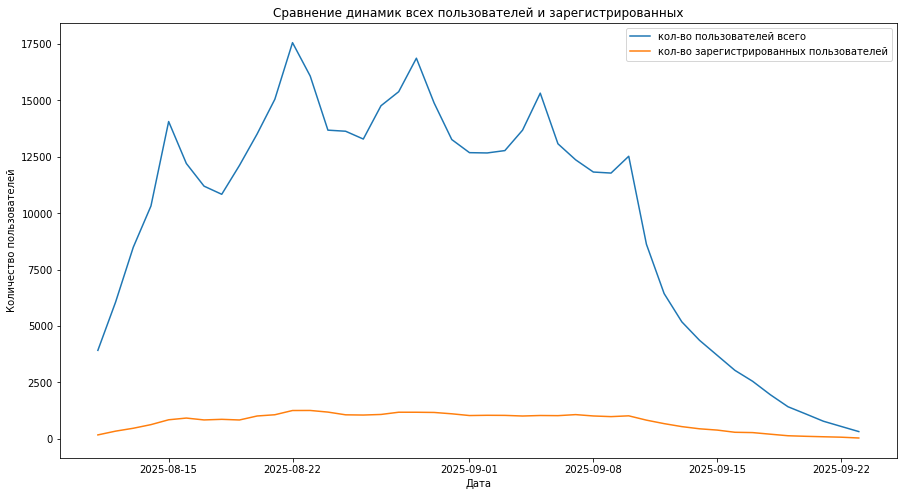

In [14]:
# Агрегируем данные для каждого дня о числе уникальных пользователей и числе зарегистрированых пользователей
date_session = (sessions_history_df.groupby('session_date').agg({'user_id': 'nunique', 'registration_flag': 'sum'})).reset_index()

# Построем линейных график по собранным данным
x = date_session.session_date
y_a = date_session.user_id
y_b = date_session.registration_flag

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='кол-во пользователей всего')
plt.plot(x, y_b, label ='кол-во зарегистрированных пользователей')

plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.legend()
plt.title('Сравнение динамик всех пользователей и зарегистрированных')
plt.show()

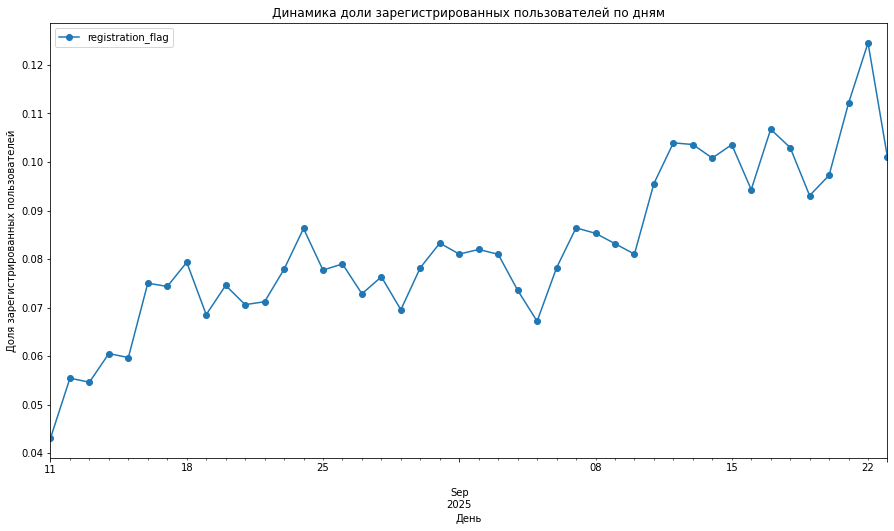

In [15]:
# Строим линейный график динамики доли зарегистрированных пользователей
sessions_history_df.groupby('session_date')['registration_flag'].mean().plot(
    kind='line',
    marker='o',
    title = 'Динамика доли зарегистрированных пользователей по дням',
    legend = True,
    figsize=(15, 8)
)

# Подписываем и отображаем график
plt.xlabel('День')
plt.ylabel('Доля зарегистрированных пользователей')
plt.show()

**Итог по разделу:**
- Динамика общего количества пользователей и количества зарегистрированы пользователей схожая, вершины находится в конце первой неделю исследуемого периода. Наблюдаются систематические скачки роста количества пользователей в выходные дни, имеется тенденция к снижению количества пользователей в конце рассматриваемого периода. 

#### 1.4. Анализ числа просмотренных страниц<a id='2.1.4'></a>

In [16]:
# Для каждого количества просмотренных страниц найдем количество уникальных сессий
page_gr = sessions_history_df.groupby('page_counter')['session_id'].nunique()
page_gr

page_counter
1     29160
2    105536
3    166690
4    105569
5     26288
6      2589
7        92
Name: session_id, dtype: int64

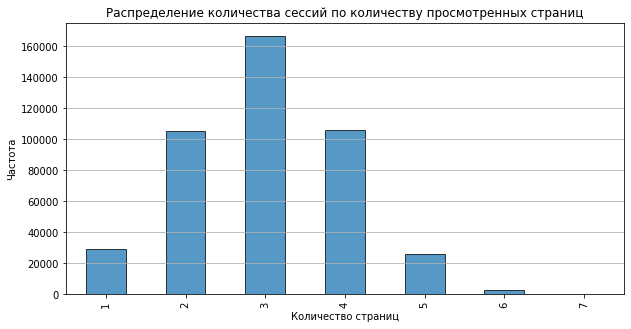

In [17]:
# Построим столбцатую лиаграмму по собранным данным 
plt.figure(figsize=(10, 5))

# Строим диаграмму
page_gr.plot(kind='bar', # Тип графика - столбчатая диаграмма
            alpha=0.75,
            edgecolor='black',
            legend=False)

# Настраиваем оформление графика
plt.title('Распределение количества сессий по количеству просмотренных страниц')
plt.xlabel('Количество страниц')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show() 


**Итог по разделу:**
- Распределение количества сессий по количеству просмотренных страниц нормальное , пик распределения смещен в левую сторону и находится в значении трех просматриваемых страниц. Имеются единичные выбросы в правом хвосте: просмотр семи страниц составляет 92 ед.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц<a id='2.1.5'></a>

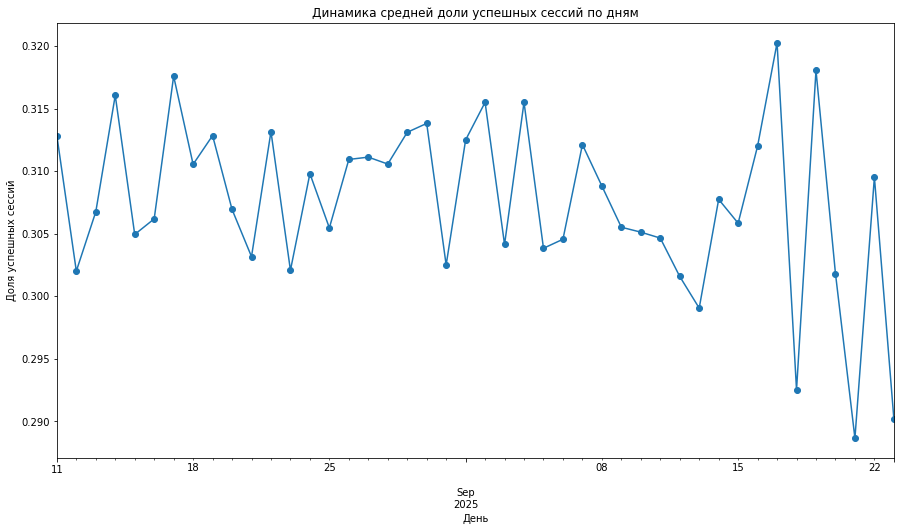

In [18]:
sessions_history_df['good_session'] = 0
sessions_history_df.loc[sessions_history_df['page_counter'] >= 4, 'good_session'] = 1

# Строим линейный график
sessions_history_df.groupby('session_date')['good_session'].mean().plot(
    kind='line',
    marker='o',
    title = 'Динамика средней доли успешных сессий по дням',
    legend = False,
    figsize=(15, 8)
)

# Подписываем и отображаем график
plt.xlabel('День')
plt.ylabel('Доля успешных сессий')
plt.show()

**Итог по разделу:**
- Выборочное среднее по количеству просматриваемых страниц находится в значении 3. Это значит, что большинство пользователей просматривает 3 страницы. В связи с этим, продуктовой команде стоит рассматривать повышение удовлетворенности и заинтересованности пользователей через повышение этого показателя. Для анализа этого показателя был создан дополнительный столбец 'good_session'.
- Согласно динамике доли успешных сессий возможно заметить, что такая доля имеет скаччки, в среднем находится в пределах 0,3-0,315. Также стоит отметить, что доля падает в конце рассматриваемого периода. 


### 2. Подготовка к тесту<a id='2.2'></a>

#### 2.1 Формулировка нулевой и альтернативной гипотез<a id='2.2.1'></a>


**Ключевая метрика:** Среднее количество просматриваемых сессий на пользователя в день

**Нулевая гипотеза:**
Среднее количество просматриваемых сессий на пользователя в день равны в группах А и В.
μ(А) = μ(В)

**Альтернативная гипотеза (одностороняя):**
В группе В среднее количество просматриваемых сессий на пользователя в день выше, чем в группе А.
μ(B) > μ(A)


#### 2.2. Расчёт размера выборки<a id='2.2.2'></a>
Установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.


In [19]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


**Итог по разделу:**
- В результате проведенного расчета было получено, что необходимый размер для каждой выборки 41 040 пользователей.
- Для расчета были заданы параметры:
        - уровень значимости 0,05 (5% вероятности ошибки первого уровня)
        - мощность теста 0,20
        - базовый уровень доли 0,3. Согласно разделу 2.1.5 динамики доли за исторический период установлено, что большую часть периода находится на уровне 0,305-0,315, на конец периода снизилась менее чем до 0,29. Следовательно, за базовый уровень принята доля до уровня снижения, цель разработки новой рекомендательной системы будет к возврату к началу "исторического" периода.
        - MDE принят в размере 3%, т.е. минимально желаемый эффект от теста будет рост доли успешных сессий до 0,309.

#### 2.3. Расчёт длительности A/B-теста<a id='2.2.3'></a>


In [20]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history_df.groupby('session_date')['user_id'].nunique().mean().round(2)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.36 пользователей в день составит 9 дней


**Итог по разделу:**
- При расчетном значении каждой выборки 41040 пользователей, длительность теста составит 9 дней.

### 3. Мониторинг А/В-теста<a id='2.3'></a>

#### 3.1. Проверка распределения пользователей<a id='2.3.1'></a>


In [21]:
# Выгружаем данные в переменные 
sessions_test_part_df = pd.read_csv('____/sessions_project_test_part.csv')

In [22]:
# Выгружаем первые 5 строк датафрейма
sessions_test_part_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [23]:
# Проверим период за который имеются первые данные теста
sessions_test_part_df['session_date'].unique()

array(['2025-10-14'], dtype=object)

In [24]:
# Рассчитаем количество пользователей в каждой группе
count_users_gr = sessions_test_part_df.groupby('test_group')['user_id'].nunique()
count_users_gr

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [25]:
# Рассчитаем долю пользователей в каждой группе
share = count_users_gr / count_users_gr.sum()
share

test_group
A    0.501869
B    0.498131
Name: user_id, dtype: float64

In [26]:
# Рассчитаем процентную разницу количества пользователей в группах
share_dif = 100 * abs(share['A'] - share['B']) / share['A']
print(f'Процентная разница в количестве пользователей в группах A и B составляет: {share_dif.round(2)}%, т.е. менее {ceil(share_dif)}%.')

Процентная разница в количестве пользователей в группах A и B составляет: 0.74%, т.е. менее 1%.


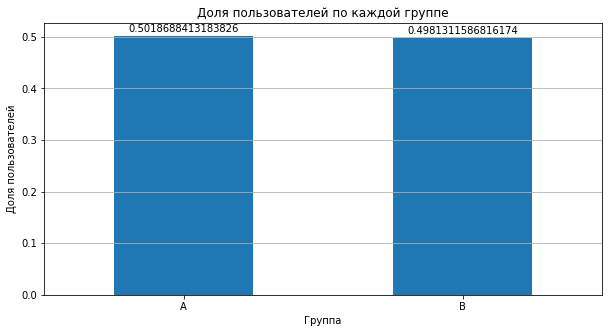

In [27]:
# Построим график столбчатой диаграммы
share.plot(kind='bar',
               title='Доля пользователей по каждой группе',
               legend=False,
               ylabel='Доля пользователей',
               xlabel='Группа',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

ax = plt.gca()
autolabel(ax.patches, share, height_factor=1.01)

# Выводим график
plt.show()

**Итог по разделу:**
- За первый день проведения эксперимента в каждой группе участвовало свыше 1450 пользователей.
- Доля пользователей по каждой группе составляет около 50%, процентная разница составляет менее 1%. Таким образом, можно говорить о равномерном распределении пользователей в каждой группе.

#### 3.2. Проверка пересечений пользователей<a id='2.3.2'></a>

In [28]:
# Выведем id пользователей, которые пересекаются в обеих группах
intersection = sessions_test_part_df.groupby('user_id').agg({'test_group': 'nunique'}).query('test_group > 1')
intersection

,test_group
user_id,


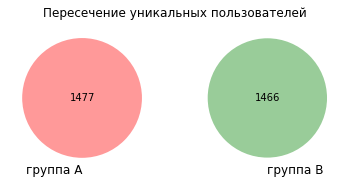

In [29]:
# Определим уникальные значения
A_id = set(sessions_test_part_df['user_id'].loc[sessions_test_part_df['test_group'] == 'A'].dropna().unique())
B_id = set(sessions_test_part_df['user_id'].loc[sessions_test_part_df['test_group'] == 'B'].dropna().unique())

# Строим диаграмму Венна
venn2([A_id, B_id], set_labels=('группа A', 'группа B'))
# Отображаем график
plt.title("Пересечение уникальных пользователей")
plt.show()

**Итог по разделу:**
- В результате проведенной проверки, в первый день эксперимента уникальные пользователи не пересекались, что также подтверждает корректность проведения эксперимента.

#### 3.3. Равномерность разделения пользователей по устройствам<a id='2.3.3'></a>

In [30]:
# рассчитаем уникальных пользователей по устройствам
total_device_a = sessions_test_part_df[sessions_test_part_df['test_group'] == 'A'].groupby('device')['user_id'].nunique()
share_device_a = round(total_device_a / total_device_a.sum() , 2)
share_device_a

device
Android    0.44
Mac        0.11
PC         0.25
iPhone     0.20
Name: user_id, dtype: float64

In [31]:
# рассчитаем уникальных пользователей по устройствам
total_device_b = sessions_test_part_df[sessions_test_part_df['test_group'] == 'B'].groupby('device')['user_id'].nunique()
share_device_b = round(total_device_b / total_device_b.sum() , 2)
share_device_b

device
Android    0.46
Mac        0.10
PC         0.26
iPhone     0.18
Name: user_id, dtype: float64

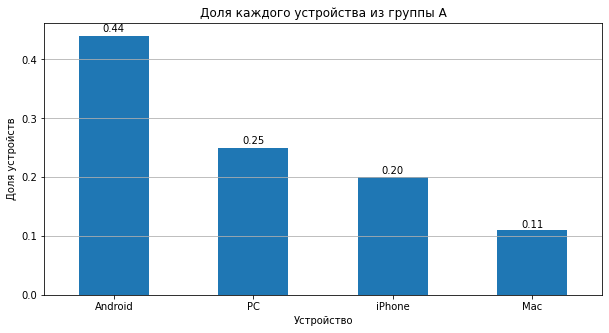

In [32]:
# Построим график столбчатой диаграммы
share_device_a.sort_values(ascending=False).plot(kind='bar',
               title='Доля каждого устройства из группы А',
               legend=False,
               ylabel='Доля устройств',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

ax = plt.gca()
autolabel(ax.patches,  height_factor=1.01)

# Выводим график
plt.show()

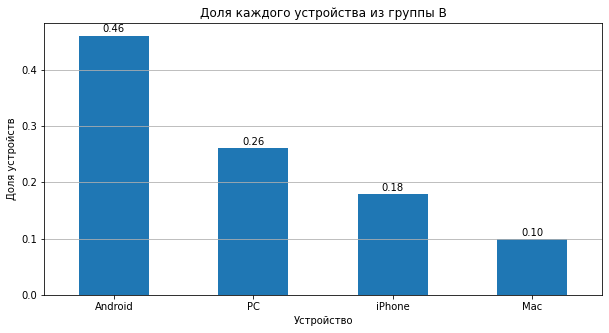

In [33]:
# Построим график столбчатой диаграммы
share_device_b.sort_values(ascending=False).plot(kind='bar',
               title='Доля каждого устройства из группы B',
               legend=False,
               ylabel='Доля устройств',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

ax = plt.gca()
autolabel(ax.patches,  height_factor=1.01)

# Выводим график
plt.show()

**Итог по разделу:**
В результате анализа распределения пользователей каждого устройства по каждой группе установлено, что пользователи распределены по используемым устройствам схоже, разница процентов составляет до 2 %. В связи с чем, можно сделать вывод о сопоставимости пользователей в каждой группе.

#### 3.4. Равномерность распределения пользователей по регионам<a id='2.3.4'></a>

In [34]:
# рассчитаем уникальных пользователей по регионам
total_region_a = sessions_test_part_df[sessions_test_part_df['test_group'] == 'A'].groupby('region')['user_id'].nunique()
share_region_a = round(total_region_a / total_region_a.sum() , 2)
share_region_a

region
CIS     0.44
EU      0.15
MENA    0.41
Name: user_id, dtype: float64

In [35]:
# рассчитаем уникальных пользователей по регионам
total_region_b = sessions_test_part_df[sessions_test_part_df['test_group'] == 'B'].groupby('region')['user_id'].nunique()
share_region_b = round(total_region_b / total_region_b.sum() , 2)
share_region_b

region
CIS     0.44
EU      0.15
MENA    0.41
Name: user_id, dtype: float64

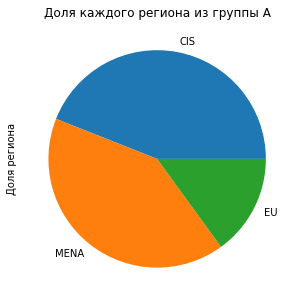

In [36]:
# Построим график столбчатой диаграммы
share_region_a.sort_values(ascending=False).plot(kind='pie',
               title='Доля каждого региона из группы А',
               legend=False,
               ylabel='Доля региона',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

# Выводим график
plt.show()

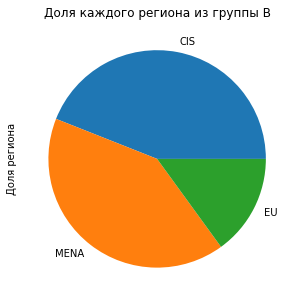

In [37]:
# Построим график столбчатой диаграммы
share_region_b.sort_values(ascending=False).plot(kind='pie',
               title='Доля каждого региона из группы B',
               legend=False,
               ylabel='Доля региона',
               xlabel='Устройство',
               rot=0,
               figsize=(10,5))
plt.grid(axis='y')

# Выводим график
plt.show()

**Итог по разделу:**
В результате анализа распределения пользователей каждого региона по каждой группе установлено, что пользователи распределены по региону схоже, разница процентов менее 1%. В связи с чем, можно сделать вывод о сопоставимости пользователей в каждой группе.

#### 3.5. Вывод после проверки A/B-теста<a id='2.3.5'></a>



- Существенного различия в количестве пользователей по каждой группе не выявлено.
- Выборки по каждой группе независимые, пересечение пользователей не выявлено.
- По категориальным переменным не выявлено существенных различий. По устройствам группы распределены равномерно с разницей процентов в один пункт, по регионам имеется бОльшее различие в 10 пунктов.

В целом возможно сделать вывод о корректности прохождения А/В-теста.

### 4. Проверка результатов A/B-теста<a id='2.4'></a>


#### 4.1. Получение результатов теста и подсчёт основной метрики<a id='2.4.1'></a>


In [38]:
# Выгружаем данные в переменные 
sessions_test_df = pd.read_csv('____/sessions_project_test.csv')

In [39]:
# Выгружаем первые 5 строк датафрейма
sessions_test_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [40]:
# Меняем тип данных на datetime64 в датафрейме
for column in ['session_date', 'session_start_ts', 'install_date']:
    sessions_test_df[column] = pd.to_datetime(sessions_test_df[column])

In [41]:
# Создадим новый столбец 'good_session' для анализа результатов 
sessions_test_df['good_session'] = 0
sessions_test_df.loc[sessions_test_df['page_counter'] >= 4, 'good_session'] = 1
sessions_test_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2. Проверка корректности результатов теста<a id='2.4.2'></a>


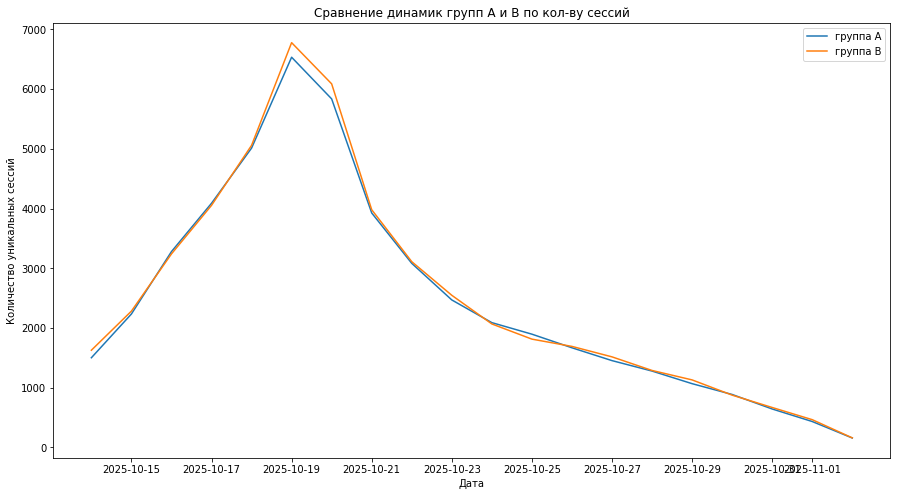

In [42]:
session_gr = sessions_test_df.groupby(['test_group', 'session_date'])['session_id'].nunique().reset_index()

x = session_gr.session_date.unique()
y_a = session_gr[session_gr.test_group=='A'].session_id
y_b = session_gr[session_gr.test_group=='B'].session_id

plt.figure(figsize=(15, 8))
plt.plot(x, y_a, label ='группа A')
plt.plot(x, y_b,label ='группа B')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных сессий")
plt.legend()
plt.title('Сравнение динамик групп A и B по кол-ву сессий')

plt.show()

**Формулировка гипотезы:**

Ключевая метрика: Количество уникальных дневных сессий

Нулевая гипотеза: Количество уникальных дневных сессий не различается μ(А) = μ(В)

Альтернативная гипотеза: Количество уникальных дневных сессий в тестовой группе В и в контрольной группе не равны А μ(B) ≠ μ(A)

In [43]:
metric_a = session_gr[session_gr.test_group=='A']['session_id'] ## выборка целевой метрики для группы A
metric_b = session_gr[session_gr.test_group=='B']['session_id'] ## выборка целевой метрики для группы B

alpha = 0.05 ## на каком уровне значимости проверяем гипотезу о равенстве выборочных средних

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_a, 
    metric_b, 
    equal_var=False,
    alternative='two-sided' ## поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки и второй выборки неравны
) ## применяем t-тест Уэлча
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
    print('Интерпретация: Создание нового алгоритма рекомендательных систем не изменило количества сессий')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны')
    print('Интерпретация: создание нового алгоритма рекомендательных систем изменило количество сессий в группе В')

p-value теста Уэлча =0.94
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны
Интерпретация: Создание нового алгоритма рекомендательных систем не изменило количества сессий


**Итог по разделу:**
- В результате анализа динамики количества пользователей по каждой группе выявлено, что количество пользователей по каждой группе за весь период эксперимента распределены равномерно.
- В результате проведения А/В-теста установлено, что нулевая гипотеза находит подтверждения. Выборочные средние (количество сессий) в группах A и B равны. Т.е. создание нового алгоритма рекомендательных систем не привело к увеличению количества сессий.

#### 4.3. Сравнение доли успешных сессий<a id='2.4.3'></a>


In [44]:
# Определим долю успешных сессий по каждой тестовой группе
p_session = sessions_test_df.groupby('test_group')['good_session'].mean()
p_session

test_group
A    0.307723
B    0.318290
Name: good_session, dtype: float64

In [45]:
# Рассчитаем процентную разницу доли успешных сессий 
p_session_dif = 100 * abs(p_session['A'] - p_session['B']) / p_session['A']

print(f'Разница в доле успешных сессий в группах A и B составляет: {p_session_dif.round(2)}%, т.е. чуть более {floor(p_session_dif)}%.')

Разница в доле успешных сессий в группах A и B составляет: 3.43%, т.е. чуть более 3%.


**Итог по разделу:**
Разница в доле успешных сессий в группах А и В составляет 3,43%, что выше заданного уровня MDE.

#### 4.4. Насколько статистически значимо изменение ключевой метрики<a id='2.4.4'></a>


In [46]:
n_a, n_b = sessions_test_df[sessions_test_df.test_group=='A'].shape[0], sessions_test_df[sessions_test_df.test_group=='B'].shape[0] ## размеры выборок A и B
m_a = sessions_test_df[(sessions_test_df.test_group=='A')&(sessions_test_df.good_session==1)].shape[0] # количество успехов в группе A
m_b = sessions_test_df[(sessions_test_df.test_group=='B')&(sessions_test_df.good_session==1)].shape[0] # количество успехов в группе B
alpha = 0.05

p_a, p_b = m_a/n_a, m_b/n_b # рассчитываем доли успехов для каждой группы: A и B

print(f'n_a={n_a}, n_b={n_b}')

print(f'm_a={m_a}, m_b={m_b}')

print(f'p_a={p_a}, p_b={p_b}')

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')
    
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' 
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

n_a=49551, n_b=50454
m_a=15248, m_b=16059
p_a=0.3077233557344958, p_b=0.31828992745867524
Предпосылка о достаточном количестве данных выполняется!
pvalue=0.0001574739988036123 < 0.05
Нулевая гипотеза не находит подтверждения!


**Итог по разделу:**
В результате проведенного Z-теста пропорций установлено, что предпосылка о достаточном количестве данных выполняется,изменение показателя является статистически значимым.
Нулевая гипотеза не находит подтверждения. 

#### 4.5. Вывод по результатам A/B-эксперимента<a id='2.4.5'></a>


**Общий вывод по результатам проведенного А/В-эксперимента**

- В результате проведенного мониторинга А/В-теста за первый день проведения эксперимента, установлено, что количество пользователей в каждой группе распределено равномерно. Для проведения эксперимента необходимо 41040 пользователей в каждой группе и 9 дней. В целом распределение по категориальным переменным равномерное.
- В соответствии с проведенным статистическим тестом Уэлча установлено, что выборочные средние в группах A и B равны, создание нового алгоритма рекомендательных систем не привело к увеличению количества сессий. Pvalue теста составил 0.47, что меньше заданного уровня значимости.
- В результате проведения Z-теста пропорций доли успешных сессий показал, что изменение показателя является статистически значимым, нулевая гипотеза не находит подтверждения. Т.е. внедрение нового алгоритма рекомендаций увеличило показатель успешных сессий.

**Таким образом, на основании проведенных статистических тестов было установлено, что внедрение нового алгоритма рекомендаций повлияло на рост ключевой метрики. Рекомендуется внедрение нововведения в приложении.**